In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jharilova/data-sentiment/3) Sentiment dataset.csv


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/jharilova/data-sentiment/3) Sentiment dataset.csv


# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

from nltk.stem import PorterStemmer

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Load and Explore Data


DATASET OVERVIEW
Dataset shape: (732, 15)

First 5 rows:
   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

          

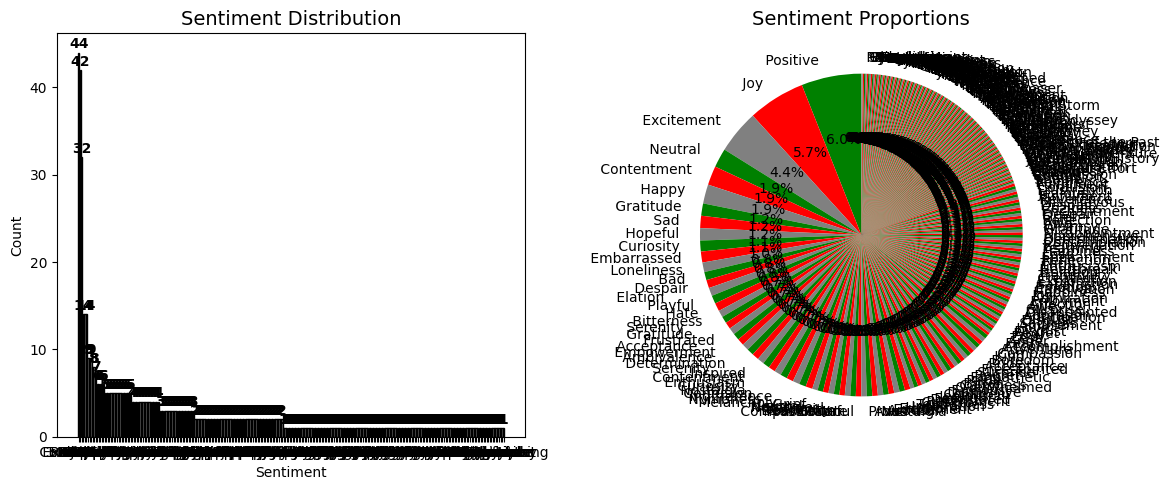

In [4]:
# Load your dataset
df = pd.read_csv('/kaggle/input/datasets/jharilova/data-sentiment/3) Sentiment dataset.csv')  

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

# Check sentiment distribution
print("\n" + "="*60)
print("SENTIMENT DISTRIBUTION")
print("="*60)
sentiment_counts = df['Sentiment'].value_counts()
print(sentiment_counts)
print(f"\nSentiment percentages:")
print(df['Sentiment'].value_counts(normalize=True) * 100)

# CRITICAL CHECK: Ensure each class has at least 2 samples
min_samples = sentiment_counts.min()
print(f"\nMinimum samples per class: {min_samples}")

if min_samples < 2:
    print("\n WARNING: Some classes have fewer than 2 samples!")
    print("This causes the stratified split error.")
    print("\nSolutions:")
    print("1. Remove classes with too few samples")
    print("2. Use regular split without stratification")
    print("3. Collect more data for minority classes")
    
    # Show which classes have problems
    problematic_classes = sentiment_counts[sentiment_counts < 2].index.tolist()
    print(f"\nProblematic classes: {problematic_classes}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
colors = ['green' if x == 'Positive' else 'red' if x == 'Negative' else 'gray' 
          for x in sentiment_counts.index]
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Sentiment Distribution', fontsize=14)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
            colors=['green', 'red', 'gray'], startangle=90)
axes[1].set_title('Sentiment Proportions', fontsize=14)

plt.tight_layout()
plt.show()

# Handle Class Imbalance 

In [5]:
# Remove classes with too few samples
print("="*60)
print("FIXING CLASS IMBALANCE ISSUE")
print("="*60)

# Check original size
original_size = len(df)
print(f"Original dataset size: {original_size}")

# Remove classes with < 2 samples
class_counts = df['Sentiment'].value_counts()
classes_to_keep = class_counts[class_counts >= 2].index.tolist()
df_balanced = df[df['Sentiment'].isin(classes_to_keep)].copy()

print(f"Classes kept: {classes_to_keep}")
print(f"New dataset size: {len(df_balanced)}")
print(f"Removed rows: {original_size - len(df_balanced)}")

# Check new distribution
print("\nNew sentiment distribution:")
print(df_balanced['Sentiment'].value_counts())

# If a class still has very few samples, consider using simple split (no stratification)
if df_balanced['Sentiment'].value_counts().min() < 2:
    print("\n Still have classes with <2 samples. Using simple split without stratification.")
    use_stratify = False
else:
    print("\n✓ All classes have at least 2 samples. Can use stratification.")
    use_stratify = True

FIXING CLASS IMBALANCE ISSUE
Original dataset size: 732
Classes kept: [' Positive  ', ' Joy ', ' Excitement ', ' Neutral ', ' Contentment ', ' Happy ', ' Gratitude ', ' Sad ', ' Hopeful ', ' Curiosity ', ' Embarrassed ', ' Loneliness ', ' Bad ', ' Despair ', ' Elation       ', ' Playful ', ' Hate ', ' Bitterness ', ' Serenity      ', ' Gratitude     ', ' Frustrated ', ' Acceptance      ', ' Empowerment   ', ' Ambivalence     ', ' Determination   ', ' Serenity        ', ' Inspired ', ' Contentment   ', ' Enthusiasm    ', ' Curiosity       ', ' Nostalgia       ', ' Confusion       ', ' Indifference    ', ' Numbness        ', ' Melancholy      ', ' Grief ', ' Neutral   ', ' Negative  ', ' Betrayal ', ' Serenity ', ' Desolation ', ' Frustration ', ' Compassionate ', ' Grateful ', ' Proud ', ' Awe ', ' Nostalgia ', ' Arousal       ', ' Excitement   ', ' Euphoria      ', ' Hope          ', ' Inspiration ', ' Tenderness    ', ' Grief           ', ' Resentment      ', ' Devastated ', ' Fearful

# Text Preprocessing Functions

In [6]:
# Initialize preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Basic text cleaning"""
    # Convert to lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove mentions and hashtags (keep the text)
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove numbers and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

def tokenize_text(text):
    """Tokenize text into words"""
    return word_tokenize(text)

def remove_stopwords(tokens):
    """Remove stopwords from tokens"""
    return [token for token in tokens if token not in stop_words]

def lemmatize_text(tokens):
    """Apply lemmatization to tokens"""
    return [lemmatizer.lemmatize(token) for token in tokens]

def preprocess_text(text):
    """Complete preprocessing pipeline"""
    # Clean text
    text = clean_text(text)
    
    # Tokenize
    tokens = tokenize_text(text)
    
    # Remove stopwords
    tokens = remove_stopwords(tokens)
    
    # Apply lemmatization
    tokens = lemmatize_text(tokens)
    
    # Join back into text
    return ' '.join(tokens)

# Test preprocessing on sample texts
print("="*60)
print("PREPROCESSING EXAMPLE")
print("="*60)
sample_texts = df_balanced['Text'].head(3).tolist()
for i, text in enumerate(sample_texts, 1):
    print(f"\nOriginal text {i}: {text}")
    print(f"Processed text {i}: {preprocess_text(text)}")

PREPROCESSING EXAMPLE

Original text 1:  Enjoying a beautiful day at the park!              
Processed text 1: enjoying beautiful day park

Original text 2:  Traffic was terrible this morning.                 
Processed text 2: traffic terrible morning

Original text 3:  Just finished an amazing workout! 💪               
Processed text 3: finished amazing workout


# Stemming vs Lemmatization — Comparison

In [7]:
stemmer = WordNetLemmatizer()   # already initialised above
porter  = PorterStemmer()

# Sample words that show a clear difference between the two techniques
sample_words = [
    'running', 'ran', 'runs',        # verb forms
    'better', 'good',                 # irregular
    'studies', 'studying', 'studied', # academic context
    'happiness', 'happily', 'happy',  # sentiment-relevant
    'caring', 'cared', 'cares',
]

print(f'{"Word":<15} {"Stemmed (Porter)":<22} {"Lemmatized (WordNet)"}')
print('-' * 60)
for word in sample_words:
    stemmed    = porter.stem(word)
    lemmatized = lemmatizer.lemmatize(word, pos='v')  # pos='v' needed for verbs
    print(f'{word:<15} {stemmed:<22} {lemmatized}')

print()
print('Key difference:')
print('  Stemming  → chops suffixes mechanically. Fast, but may produce non-words.')
print('  Lemmatization → maps to the dictionary base form. Slower, but always a real word.')
print()
print('Choice for this project: Lemmatization')
print('Reason: sentiment words like "happy", "good", "loving" must stay readable.')
print('        Stemming would turn "happily" into "happili" — not meaningful for NLP.')

Word            Stemmed (Porter)       Lemmatized (WordNet)
------------------------------------------------------------
running         run                    run
ran             ran                    run
runs            run                    run
better          better                 better
good            good                   good
studies         studi                  study
studying        studi                  study
studied         studi                  study
happiness       happi                  happiness
happily         happili                happily
happy           happi                  happy
caring          care                   care
cared           care                   care
cares           care                   care

Key difference:
  Stemming  → chops suffixes mechanically. Fast, but may produce non-words.
  Lemmatization → maps to the dictionary base form. Slower, but always a real word.

Choice for this project: Lemmatization
Reason: sentiment words like "happy

# Apply Preprocessing to All Texts

In [8]:
# Apply preprocessing to all texts
print("Applying preprocessing to all texts...")
df_balanced['cleaned_text'] = df_balanced['Text'].apply(preprocess_text)

# Display results
print("\n" + "="*60)
print("PREPROCESSING RESULTS")
print("="*60)
print(f"\nOriginal text sample:")
print(df_balanced['Text'].iloc[0])
print(f"\nCleaned text sample:")
print(df_balanced['cleaned_text'].iloc[0])

# Check text lengths
df_balanced['text_length'] = df_balanced['cleaned_text'].apply(lambda x: len(x.split()))
print(f"\nAverage text length: {df_balanced['text_length'].mean():.2f} words")
print(f"Max text length: {df_balanced['text_length'].max()} words")
print(f"Min text length: {df_balanced['text_length'].min()} words")

# Remove empty texts (if any)
empty_texts = df_balanced[df_balanced['cleaned_text'] == '']
if len(empty_texts) > 0:
    print(f"\n Found {len(empty_texts)} empty texts. Removing them...")
    df_balanced = df_balanced[df_balanced['cleaned_text'] != '']

Applying preprocessing to all texts...

PREPROCESSING RESULTS

Original text sample:
 Enjoying a beautiful day at the park!              

Cleaned text sample:
enjoying beautiful day park

Average text length: 7.88 words
Max text length: 15 words
Min text length: 3 words


#  Train-Test Split

In [9]:
# Prepare features and labels
X = df_balanced['cleaned_text']
y = df_balanced['Sentiment']

# Choose splitting strategy
if use_stratify and len(df_balanced) > 0:
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        print("Used stratified split (maintains class distribution)")
    except ValueError as e:
        print(f"Stratified split failed: {e}")
        print("Falling back to simple random split...")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print("Used simple random split (no stratification)")

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

# Check class distribution in splits
print("\nTraining set distribution:")
print(y_train.value_counts())
print("\nTest set distribution:")
print(y_test.value_counts())

Stratified split failed: The test_size = 118 should be greater or equal to the number of classes = 134
Falling back to simple random split...

Training set size: 469
Testing set size: 118

Training set distribution:
Sentiment
Positive            38
Joy                 36
Excitement          23
Contentment         13
Neutral             12
                    ..
Ambivalence          1
Love                 1
Apprehensive         1
Awe                  1
Reflection           1
Name: count, Length: 128, dtype: int64

Test set distribution:
Sentiment
Excitement          9
Joy                 6
Positive            6
Happy               5
Sad                 4
                   ..
Neutral             1
Indifference        1
Contemplation       1
Fulfillment         1
Grief               1
Name: count, Length: 67, dtype: int64


# Convert Text to Numerical Features (TF-IDF)

In [10]:
# Create TF-IDF features
print("\n" + "="*60)
print("TF-IDF FEATURE EXTRACTION")
print("="*60)

# TF-IDF with appropriate parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Limit features for better performance
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=2,  # Ignore terms that appear in less than 2 documents
    max_df=0.95  # Ignore terms that appear in more than 95% of documents
)

# Fit and transform
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF feature matrix shape: {X_train_tfidf.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")

# Show top features
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_scores = X_train_tfidf.mean(axis=0).A1
top_features = sorted(zip(feature_names, feature_scores), key=lambda x: x[1], reverse=True)[:20]
print(f"\nTop 20 features by TF-IDF score:")
for feature, score in top_features:
    print(f"  {feature}: {score:.4f}")


TF-IDF FEATURE EXTRACTION
TF-IDF feature matrix shape: (469, 962)
Number of features: 962

Top 20 features by TF-IDF score:
  new: 0.0218
  life: 0.0165
  day: 0.0143
  friend: 0.0135
  feeling: 0.0132
  moment: 0.0119
  like: 0.0116
  joy: 0.0115
  challenge: 0.0108
  dream: 0.0107
  heart: 0.0101
  beauty: 0.0098
  time: 0.0097
  world: 0.0097
  lost: 0.0096
  journey: 0.0095
  emotion: 0.0094
  project: 0.0094
  art: 0.0090
  school: 0.0088


# Train Classification Models

In [11]:
# Define models to train
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42, probability=True)
}

# Train and evaluate each model
results = {}
predictions = {}

print("="*60)
print("MODEL TRAINING AND EVALUATION")
print("="*60)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    try:
        # Train model
        model.fit(X_train_tfidf, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test_tfidf)
        predictions[name] = y_pred
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # Store results
        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        }
        
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        
    except Exception as e:
        print(f"  Error training {name}: {e}")
        results[name] = {'Accuracy': 0, 'Precision': 0, 'Recall': 0, 'F1-Score': 0}

# Display results as DataFrame
results_df = pd.DataFrame(results).T
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(results_df.round(4))

MODEL TRAINING AND EVALUATION

Training Naive Bayes...
  Accuracy: 0.0847
  Precision: 0.0088
  Recall: 0.0847
  F1-Score: 0.0159

Training Logistic Regression...
  Accuracy: 0.1017
  Precision: 0.0218
  Recall: 0.1017
  F1-Score: 0.0304

Training SVM...
  Accuracy: 0.2373
  Precision: 0.1488
  Recall: 0.2373
  F1-Score: 0.1628

MODEL PERFORMANCE SUMMARY
                     Accuracy  Precision  Recall  F1-Score
Naive Bayes            0.0847     0.0088  0.0847    0.0159
Logistic Regression    0.1017     0.0218  0.1017    0.0304
SVM                    0.2373     0.1488  0.2373    0.1628


# Confusion Matrices

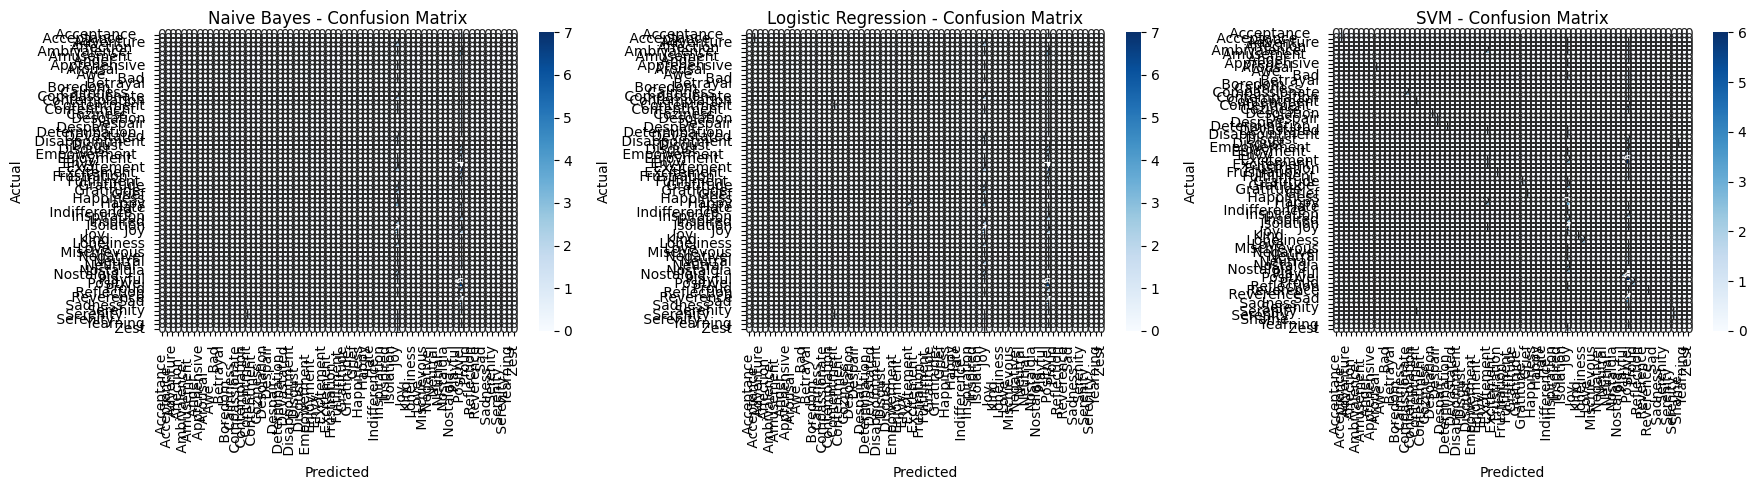


DETAILED CLASSIFICATION REPORT - SVM
                   precision    recall  f1-score   support

    Acceptance          0.00      0.00      0.00         1
 Acceptance             0.50      1.00      0.67         1
       Adventure        0.00      0.00      0.00         2
    Affection           0.00      0.00      0.00         1
 Ambivalence            0.00      0.00      0.00         4
    Amusement           0.00      0.00      0.00         1
    Anger               0.00      0.00      0.00         1
    Apprehensive        0.00      0.00      0.00         1
   Arousal              1.00      1.00      1.00         1
    Awe                 0.00      0.00      0.00         1
             Bad        0.00      0.00      0.00         2
        Betrayal        0.00      0.00      0.00         1
 Boredom                0.00      0.00      0.00         1
    Calmness            0.00      0.00      0.00         1
   Compassionate        1.00      1.00      1.00         2
   Contemplation 

In [12]:
# Plot confusion matrices for models that worked
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred) in enumerate(predictions.items()):
    if len(y_pred) > 0:
        # Get unique labels
        labels = sorted(set(y_test) | set(y_pred))
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=labels, yticklabels=labels, ax=axes[idx])
        axes[idx].set_title(f'{name} - Confusion Matrix')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Detailed classification report for best model
if len(predictions) > 0:
    best_model_name = results_df['F1-Score'].idxmax()
    y_pred_best = predictions[best_model_name]
    
    print("\n" + "="*60)
    print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")
    print("="*60)
    print(classification_report(y_test, y_pred_best, zero_division=0))

# Feature Importance Analysis (for Logistic Regression)

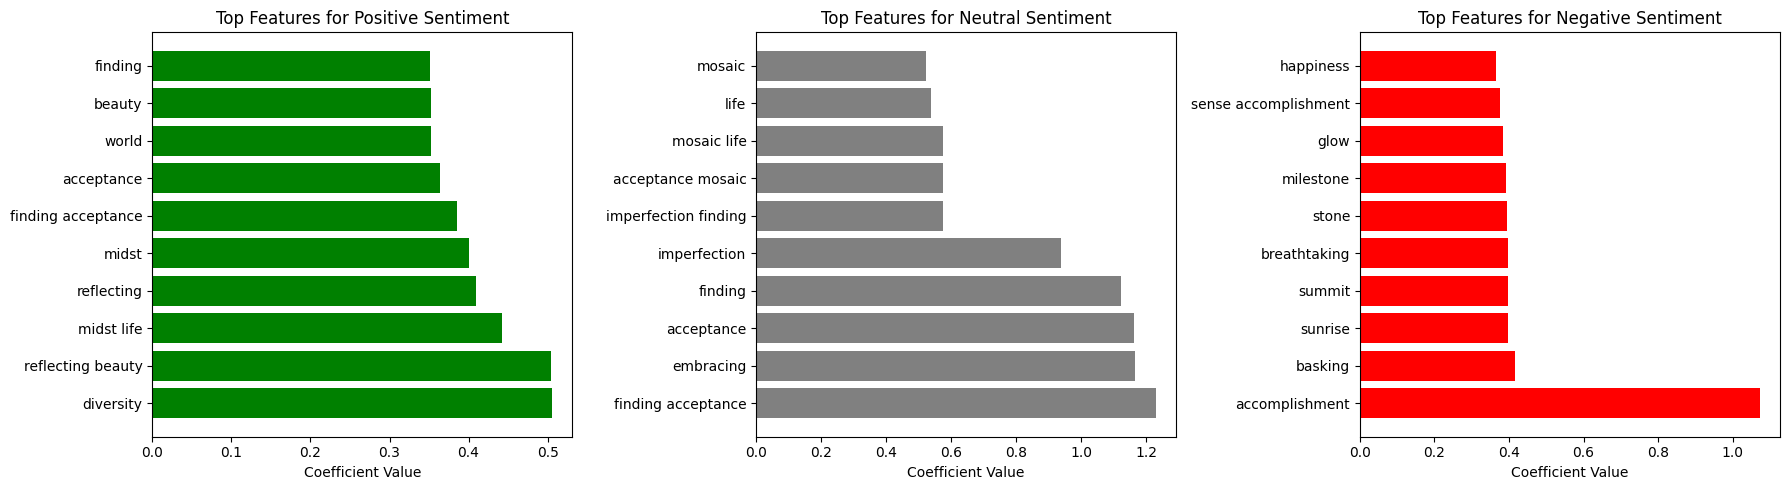

In [13]:
# Analyze feature importance for Logistic Regression
if 'Logistic Regression' in models:
    lr_model = models['Logistic Regression']
    feature_names = tfidf_vectorizer.get_feature_names_out()
    coefficients = lr_model.coef_[0]
    
    # Get top positive and negative features for each sentiment
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sentiments = ['Positive', 'Neutral', 'Negative']
    for idx, sentiment in enumerate(sentiments):
        # For multi-class, we need to analyze differently
        if len(lr_model.coef_) > 1:
            coef = lr_model.coef_[idx]
        else:
            coef = coefficients
        
        # Get top features
        top_features_idx = coef.argsort()[-10:][::-1]
        top_features = [feature_names[i] for i in top_features_idx]
        top_coef = [coef[i] for i in top_features_idx]
        
        # Plot
        axes[idx].barh(top_features, top_coef, color='green' if idx == 0 else 'gray' if idx == 1 else 'red')
        axes[idx].set_title(f'Top Features for {sentiment} Sentiment')
        axes[idx].set_xlabel('Coefficient Value')
    
    plt.tight_layout()
    plt.show()

# Test with New Text Examples

In [14]:
# Function to predict sentiment of new text
def predict_sentiment(text, model, vectorizer):
    """Predict sentiment of new text"""
    # Preprocess text
    cleaned = preprocess_text(text)
    
    # Transform using TF-IDF
    text_tfidf = vectorizer.transform([cleaned])
    
    # Predict
    prediction = model.predict(text_tfidf)[0]
    
    # Get probability if available
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(text_tfidf)[0]
        confidence = max(proba) * 100
    else:
        confidence = None
    
    return prediction, confidence

# Test with custom examples
if len(predictions) > 0:
    best_model = models[best_model_name]
    
    test_examples = [
        "I absolutely love this! It's amazing!",
        "This is terrible, worst experience ever.",
        "The weather is okay, nothing special.",
        "I'm so happy with the results! Highly recommend!",
        "Disappointed with the service, very slow.",
        "It's fine, average experience."
    ]
    
    print("="*60)
    print("TESTING MODEL WITH CUSTOM TEXTS")
    print("="*60)
    
    for text in test_examples:
        prediction, confidence = predict_sentiment(text, best_model, tfidf_vectorizer)
        print(f"\nText: {text}")
        print(f"Predicted Sentiment: {prediction}")
        if confidence:
            print(f"Confidence: {confidence:.1f}%")

TESTING MODEL WITH CUSTOM TEXTS

Text: I absolutely love this! It's amazing!
Predicted Sentiment:  Joy 
Confidence: 6.5%

Text: This is terrible, worst experience ever.
Predicted Sentiment:  Positive  
Confidence: 7.0%

Text: The weather is okay, nothing special.
Predicted Sentiment:  Positive  
Confidence: 10.2%

Text: I'm so happy with the results! Highly recommend!
Predicted Sentiment:  Positive  
Confidence: 12.0%

Text: Disappointed with the service, very slow.
Predicted Sentiment:  Disappointed 
Confidence: 6.6%

Text: It's fine, average experience.
Predicted Sentiment:  Positive  
Confidence: 7.0%


# Visual Comparison



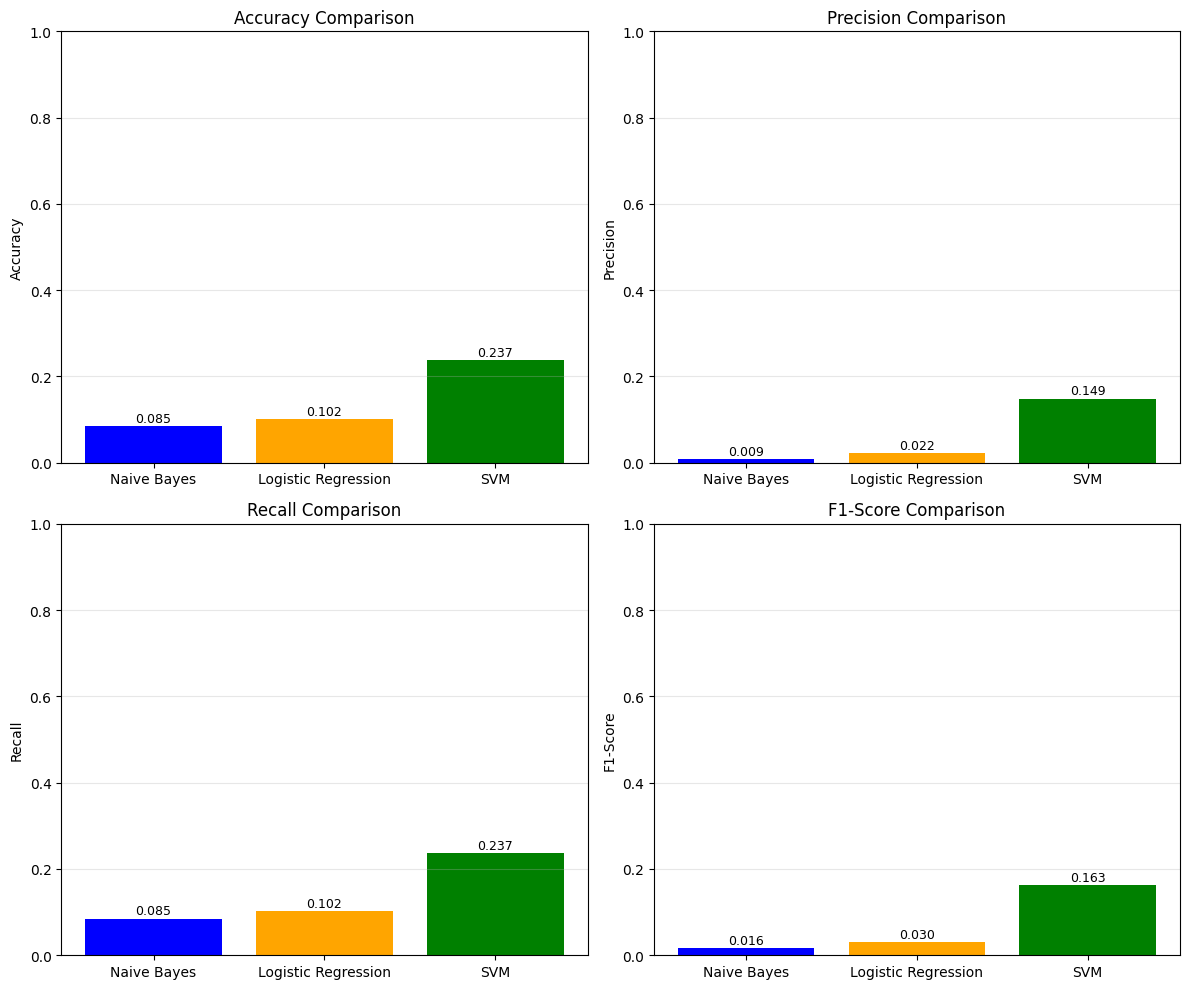


FINAL SUMMARY
✓ Best Model: SVM
✓ Best F1-Score: 0.1628
✓ Test set size: 118 samples


In [15]:
# Visual comparison of all models
if len(results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    for idx, metric in enumerate(metrics):
        row, col = idx // 2, idx % 2
        valid_models = [m for m in results_df.index if results_df.loc[m, metric] > 0]
        if valid_models:
            values = [results_df[metric][model] for model in valid_models]
            bars = axes[row, col].bar(valid_models, values, color=['blue', 'orange', 'green'][:len(valid_models)])
            axes[row, col].set_title(f'{metric} Comparison')
            axes[row, col].set_ylabel(metric)
            axes[row, col].set_ylim(0, 1)
            axes[row, col].grid(True, alpha=0.3, axis='y')
            
            # Add value labels
            for bar, value in zip(bars, values):
                axes[row, col].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                                   f'{value:.3f}', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Print final summary
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
if len(results) > 0:
    best_model = results_df['F1-Score'].idxmax()
    best_f1 = results_df.loc[best_model, 'F1-Score']
    print(f"✓ Best Model: {best_model}")
    print(f"✓ Best F1-Score: {best_f1:.4f}")
    print(f"✓ Test set size: {len(y_test)} samples")
else:
    print(" No models were successfully trained. Check your data.")

# Save Model for Future Use 

In [16]:
# Save the best model and vectorizer for future use
import joblib

# Save best model
best_model_name = results_df['F1-Score'].idxmax()
best_model = models[best_model_name]

joblib.dump(best_model, 'sentiment_model.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")
print(f"Saved files: sentiment_model.pkl, tfidf_vectorizer.pkl")

# Function to load and use saved model
def load_and_predict(text):
    model = joblib.load('sentiment_model.pkl')
    vectorizer = joblib.load('tfidf_vectorizer.pkl')
    prediction, confidence = predict_sentiment(text, model, vectorizer)
    return prediction, confidence

# Test loading
print("\nTesting saved model:")
test_text = "This is a great example!"
pred, conf = load_and_predict(test_text)
print(f"Text: {test_text}")
print(f"Prediction: {pred} (Confidence: {conf:.1f}%)")

Model and vectorizer saved successfully!
Saved files: sentiment_model.pkl, tfidf_vectorizer.pkl

Testing saved model:
Text: This is a great example!
Prediction:  Joy  (Confidence: 7.4%)
